<a href="https://colab.research.google.com/github/orionrjsun-collab/BUS4-118s/blob/main/AgenticAISupplyChain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

rng = np.random.default_rng(42)

dates = pd.date_range('2024-01-01', periods=90, freq='D')
skus = ['SKU-A', 'SKU-B']

rows = []
for sku in skus:
    base_demand = 20 if sku == 'SKU-A' else 10
    for date in dates:
        qty = int(max(0, rng.normal(base_demand, 5)))
        rows.append({'date': date.strftime('%Y-%m-%d'), 'sku': sku, 'qty_sold': qty})

pd.DataFrame(rows).to_csv('sales.csv', index=False)
print("sales.csv created")

sales.csv created


In [2]:
inventory_data = [
    {'sku': 'SKU-A', 'opening_stock': 150},
    {'sku': 'SKU-B', 'opening_stock': 80}
]
pd.DataFrame(inventory_data).to_csv('inventory.csv', index=False)
print("inventory.csv created")

inventory.csv created


In [3]:
params_data = [
    {
        'sku': 'SKU-A',
        'unit_cost': 10.0,
        'holding_cost_per_day': 0.05,
        'stockout_cost': 5.0,
        'lead_time_days': 5,
        'min_order_qty': 50,
        'service_level': 0.95
    },
    {
        'sku': 'SKU-B',
        'unit_cost': 25.0,
        'holding_cost_per_day': 0.10,
        'stockout_cost': 15.0,
        'lead_time_days': 3,
        'min_order_qty': 30,
        'service_level': 0.90
    }
]
pd.DataFrame(params_data).to_csv('params.csv', index=False)
print("params.csv created")

params.csv created


In [4]:
import pandas as pd
import numpy as np

# Load the CSV files
sales_df = pd.read_csv('sales.csv', parse_dates=['date'])
inventory_df = pd.read_csv('inventory.csv')
params_df = pd.read_csv('params.csv')

# Aggregate: sum qty_sold by date and sku
# (in case there are multiple rows for the same date/sku)
demand_df = (
    sales_df
    .groupby(['date', 'sku'], as_index=False)['qty_sold']
    .sum()
    .sort_values(['sku', 'date'])
    .reset_index(drop=True)
)

print(demand_df.head(10))
print(f"\nDate range: {demand_df['date'].min()} to {demand_df['date'].max()}")
print(f"SKUs: {demand_df['sku'].unique()}")

        date    sku  qty_sold
0 2024-01-01  SKU-A        21
1 2024-01-02  SKU-A        14
2 2024-01-03  SKU-A        23
3 2024-01-04  SKU-A        24
4 2024-01-05  SKU-A        10
5 2024-01-06  SKU-A        13
6 2024-01-07  SKU-A        20
7 2024-01-08  SKU-A        18
8 2024-01-09  SKU-A        19
9 2024-01-10  SKU-A        15

Date range: 2024-01-01 00:00:00 to 2024-03-30 00:00:00
SKUs: ['SKU-A' 'SKU-B']


In [5]:
def compute_ewma_forecast(demand_series, alpha=0.3):
    """
    Compute EWMA forecast for a single SKU's demand series.
    Returns a Series of forecasted values (one per day).
    The forecast for day t is computed using data up to day t-1.
    """
    forecasts = []
    # Initialize with the first actual value
    current_forecast = demand_series.iloc[0]

    for i, actual in enumerate(demand_series):
        forecasts.append(current_forecast)
        # Update forecast using actual observation
        current_forecast = alpha * actual + (1 - alpha) * current_forecast

    return pd.Series(forecasts, index=demand_series.index)


def compute_forecast_error_std(demand_series, alpha=0.3):
    """
    Compute the standard deviation of forecast errors.
    Used for safety stock calculation.
    """
    forecasts = compute_ewma_forecast(demand_series, alpha)
    errors = demand_series - forecasts
    return errors.std()


# Apply to each SKU
forecast_results = {}

for sku in demand_df['sku'].unique():
    sku_demand = demand_df[demand_df['sku'] == sku].set_index('date')['qty_sold']
    forecast = compute_ewma_forecast(sku_demand, alpha=0.3)
    error_std = compute_forecast_error_std(sku_demand, alpha=0.3)

    forecast_results[sku] = {
        'demand': sku_demand,
        'forecast': forecast,
        'error_std': error_std
    }

    print(f"{sku}: avg demand = {sku_demand.mean():.2f}, "
          f"forecast error std = {error_std:.2f}")

SKU-A: avg demand = 19.54, forecast error std = 4.22
SKU-B: avg demand = 8.89, forecast error std = 5.24


In [6]:
from scipy.stats import norm

def compute_safety_stock(error_std, lead_time_days, service_level):
    """
    Compute safety stock.

    error_std: standard deviation of daily forecast errors
    lead_time_days: how many days until an order arrives
    service_level: e.g. 0.95 means 95% chance of not stocking out
    """
    z = norm.ppf(service_level)  # z-score for the service level
    # Uncertainty compounds over the lead time
    safety_stock = z * error_std * np.sqrt(lead_time_days)
    return max(0, safety_stock)


def compute_reorder_point(avg_daily_demand, lead_time_days, safety_stock):
    """
    Reorder Point = expected demand during lead time + safety stock
    """
    return avg_daily_demand * lead_time_days + safety_stock


# Compute safety stock and reorder points for each SKU
sku_params = {}

for _, row in params_df.iterrows():
    sku = row['sku']
    error_std = forecast_results[sku]['error_std']
    avg_demand = forecast_results[sku]['demand'].mean()

    ss = compute_safety_stock(
        error_std=error_std,
        lead_time_days=row['lead_time_days'],
        service_level=row['service_level']
    )

    rop = compute_reorder_point(
        avg_daily_demand=avg_demand,
        lead_time_days=row['lead_time_days'],
        safety_stock=ss
    )

    sku_params[sku] = {
        **row.to_dict(),           # all the params from CSV
        'avg_daily_demand': avg_demand,
        'error_std': error_std,
        'safety_stock': ss,
        'reorder_point': rop
    }

    print(f"\n{sku}:")
    print(f"  Avg daily demand:  {avg_demand:.2f}")
    print(f"  Forecast error std:{error_std:.2f}")
    print(f"  Safety stock:      {ss:.2f}")
    print(f"  Reorder point:     {rop:.2f}")


SKU-A:
  Avg daily demand:  19.54
  Forecast error std:4.22
  Safety stock:      15.50
  Reorder point:     113.23

SKU-B:
  Avg daily demand:  8.89
  Forecast error std:5.24
  Safety stock:      11.63
  Reorder point:     38.29


In [7]:
from collections import defaultdict

class InventoryAgent:
    """
    A single-SKU inventory replenishment agent.
    Tracks stock, pending orders, and costs.
    """

    def __init__(self, sku, opening_stock, params):
        self.sku = sku
        self.on_hand = opening_stock
        self.params = params          # dict from sku_params[sku]

        # Pipeline: dict of {arrival_date -> qty}
        # Orders placed today arrive after lead_time_days
        self.pipeline = defaultdict(int)

        # Tracking
        self.log = []
        self.total_holding_cost = 0.0
        self.total_stockout_cost = 0.0
        self.total_order_cost = 0.0
        self.total_units_demanded = 0
        self.total_units_filled = 0

    def inventory_position(self):
        """On-hand + all pending orders in the pipeline."""
        return self.on_hand + sum(self.pipeline.values())

    def projected_inventory(self, current_date, forecast):
        """
        Project inventory over the lead time using the EWMA forecast.
        Returns projected on-hand at end of lead time.
        """
        lead_time = self.params['lead_time_days']
        projected = self.on_hand

        # Add any orders arriving within the lead time
        for day_offset in range(lead_time):
            arrival_date = current_date + pd.Timedelta(days=day_offset)
            projected += self.pipeline.get(arrival_date, 0)

        # Subtract expected demand over the lead time
        projected -= forecast * lead_time

        return projected

    def decide(self, current_date, actual_demand, forecast):
        """
        Main agent decision logic for one day.
        Returns the action taken and rationale string.
        """
        lead_time = self.params['lead_time_days']
        min_order = self.params['min_order_qty']
        rop = self.params['reorder_point']
        holding_rate = self.params['holding_cost_per_day']
        stockout_cost_rate = self.params['stockout_cost']

        # --- RECEIVE ORDERS ---
        arriving_today = self.pipeline.pop(current_date, 0)
        self.on_hand += arriving_today

        # --- FILL DEMAND ---
        units_filled = min(self.on_hand, actual_demand)
        units_short = max(0, actual_demand - self.on_hand)
        self.on_hand = max(0, self.on_hand - actual_demand)

        # --- ACCUMULATE COSTS ---
        self.total_holding_cost += holding_rate * max(0, self.on_hand)
        self.total_stockout_cost += stockout_cost_rate * units_short
        self.total_units_demanded += actual_demand
        self.total_units_filled += units_filled

        # --- ORDER DECISION ---
        inv_position = self.inventory_position()
        proj_inv = self.projected_inventory(current_date, forecast)
        action = "WAIT"
        order_qty = 0
        rationale = ""

        if inv_position <= rop:
            # Inventory position dropped below reorder point — order!
            # Order enough to cover lead time demand + safety stock
            target = (self.params['avg_daily_demand']
                      * (lead_time + 1)              # lead time + 1 review day
                      + self.params['safety_stock'])

            order_qty = max(min_order, int(np.ceil(target - inv_position)))
            order_qty = int(np.ceil(order_qty / min_order) * min_order)  # round up to MOQ

            arrival_date = current_date + pd.Timedelta(days=lead_time)
            self.pipeline[arrival_date] += order_qty
            self.total_order_cost += 50  # fixed cost per PO (can be 0 as assignment says)

            action = f"ORDER {order_qty} units"
            rationale = (
                f"Inv position {inv_position:.0f} <= ROP {rop:.0f}. "
                f"Projected inv at LT end: {proj_inv:.0f}. "
                f"Ordered {order_qty} arriving {arrival_date.date()}."
            )
        else:
            rationale = (
                f"Inv position {inv_position:.0f} > ROP {rop:.0f}. "
                f"Projected inv at LT end: {proj_inv:.0f}. No order needed."
            )

        # --- LOG THE DAY ---
        log_entry = {
            'date': current_date.date(),
            'sku': self.sku,
            'actual_demand': actual_demand,
            'forecast': round(forecast, 2),
            'arrived': arriving_today,
            'on_hand_eod': self.on_hand,
            'units_short': units_short,
            'inv_position': inv_position,
            'action': action,
            'rationale': rationale
        }
        self.log.append(log_entry)

        return action, rationale

    def kpis(self):
        """Return summary KPIs for this SKU."""
        fill_rate = (self.total_units_filled / self.total_units_demanded
                     if self.total_units_demanded > 0 else 1.0)
        return {
            'sku': self.sku,
            'fill_rate': round(fill_rate, 4),
            'holding_cost': round(self.total_holding_cost, 2),
            'order_cost': round(self.total_order_cost, 2),
            'stockout_cost': round(self.total_stockout_cost, 2),
            'total_cost': round(
                self.total_holding_cost + self.total_order_cost + self.total_stockout_cost, 2
            )
        }

In [8]:
# Get sorted list of all unique dates
all_dates = sorted(demand_df['date'].unique())

# Initialize one agent per SKU
agents = {}
for _, row in inventory_df.iterrows():
    sku = row['sku']
    agents[sku] = InventoryAgent(
        sku=sku,
        opening_stock=row['opening_stock'],
        params=sku_params[sku]
    )

# Run the simulation day by day
for date in all_dates:
    for sku, agent in agents.items():
        # Get actual demand for this day (0 if missing)
        day_data = demand_df[
            (demand_df['date'] == date) & (demand_df['sku'] == sku)
        ]
        actual_demand = int(day_data['qty_sold'].values[0]) if len(day_data) > 0 else 0

        # Get EWMA forecast for this day
        forecast_series = forecast_results[sku]['forecast']
        forecast = float(forecast_series.loc[date]) if date in forecast_series.index else sku_params[sku]['avg_daily_demand']

        # Agent decides and acts
        action, rationale = agent.decide(date, actual_demand, forecast)

print("Simulation complete!")
print(f"Days simulated: {len(all_dates)}")

Simulation complete!
Days simulated: 90


In [9]:
# Combine logs from all agents into one DataFrame
all_logs = []
for sku, agent in agents.items():
    all_logs.extend(agent.log)

log_df = pd.DataFrame(all_logs).sort_values(['date', 'sku']).reset_index(drop=True)

# Print log for each SKU
for sku in sorted(agents.keys()):
    print(f"\n{'='*70}")
    print(f"DAILY AGENT LOG — {sku}")
    print(f"{'='*70}")

    sku_log = log_df[log_df['sku'] == sku]

    for _, row in sku_log.iterrows():
        print(
            f"[{row['date']}] "
            f"Demand: {row['actual_demand']:3d} | "
            f"Forecast: {row['forecast']:5.1f} | "
            f"Arrived: {row['arrived']:3d} | "
            f"OnHand EOD: {row['on_hand_eod']:4d} | "
            f"Short: {row['units_short']:3d} | "
            f"Action: {row['action']}"
        )
        print(f"         Rationale: {row['rationale']}")


DAILY AGENT LOG — SKU-A
[2024-01-01] Demand:  21 | Forecast:  21.0 | Arrived:   0 | OnHand EOD:  129 | Short:   0 | Action: WAIT
         Rationale: Inv position 129 > ROP 113. Projected inv at LT end: 24. No order needed.
[2024-01-02] Demand:  14 | Forecast:  21.0 | Arrived:   0 | OnHand EOD:  115 | Short:   0 | Action: WAIT
         Rationale: Inv position 115 > ROP 113. Projected inv at LT end: 10. No order needed.
[2024-01-03] Demand:  23 | Forecast:  18.9 | Arrived:   0 | OnHand EOD:   92 | Short:   0 | Action: ORDER 50 units
         Rationale: Inv position 92 <= ROP 113. Projected inv at LT end: -2. Ordered 50 arriving 2024-01-08.
[2024-01-04] Demand:  24 | Forecast:  20.1 | Arrived:   0 | OnHand EOD:   68 | Short:   0 | Action: WAIT
         Rationale: Inv position 118 > ROP 113. Projected inv at LT end: 17. No order needed.
[2024-01-05] Demand:  10 | Forecast:  21.3 | Arrived:   0 | OnHand EOD:   58 | Short:   0 | Action: ORDER 50 units
         Rationale: Inv position 108 <=

In [10]:
# Per-SKU KPIs
print("\n" + "="*70)
print("SIMULATION RESULTS — KPI SUMMARY")
print("="*70)

kpi_rows = []
for sku, agent in agents.items():
    kpis = agent.kpis()
    kpi_rows.append(kpis)

    print(f"\n{sku}:")
    print(f"  Fill Rate:      {kpis['fill_rate']*100:.2f}%")
    print(f"  Holding Cost:   ${kpis['holding_cost']:,.2f}")
    print(f"  Order Cost:     ${kpis['order_cost']:,.2f}")
    print(f"  Stockout Cost:  ${kpis['stockout_cost']:,.2f}")
    print(f"  Total Cost:     ${kpis['total_cost']:,.2f}")

# Aggregate across all SKUs
kpi_df = pd.DataFrame(kpi_rows)
total_row = {
    'sku': 'TOTAL',
    'fill_rate': (kpi_df['fill_rate'].mean()),  # avg fill rate
    'holding_cost': kpi_df['holding_cost'].sum(),
    'order_cost': kpi_df['order_cost'].sum(),
    'stockout_cost': kpi_df['stockout_cost'].sum(),
    'total_cost': kpi_df['total_cost'].sum()
}

print(f"\n{'='*70}")
print("AGGREGATE:")
print(f"  Avg Fill Rate:  {total_row['fill_rate']*100:.2f}%")
print(f"  Total Cost:     ${total_row['total_cost']:,.2f}")
print(f"    Holding:      ${total_row['holding_cost']:,.2f}")
print(f"    Order:        ${total_row['order_cost']:,.2f}")
print(f"    Stockout:     ${total_row['stockout_cost']:,.2f}")

# Save KPI table
kpi_df.to_csv('kpi_results.csv', index=False)
print("\nKPI table saved to kpi_results.csv")


SIMULATION RESULTS — KPI SUMMARY

SKU-A:
  Fill Rate:      100.00%
  Holding Cost:   $202.55
  Order Cost:     $1,750.00
  Stockout Cost:  $0.00
  Total Cost:     $1,952.55

SKU-B:
  Fill Rate:      98.38%
  Holding Cost:   $243.10
  Order Cost:     $1,250.00
  Stockout Cost:  $195.00
  Total Cost:     $1,688.10

AGGREGATE:
  Avg Fill Rate:  99.19%
  Total Cost:     $3,640.65
    Holding:      $445.65
    Order:        $3,000.00
    Stockout:     $195.00

KPI table saved to kpi_results.csv


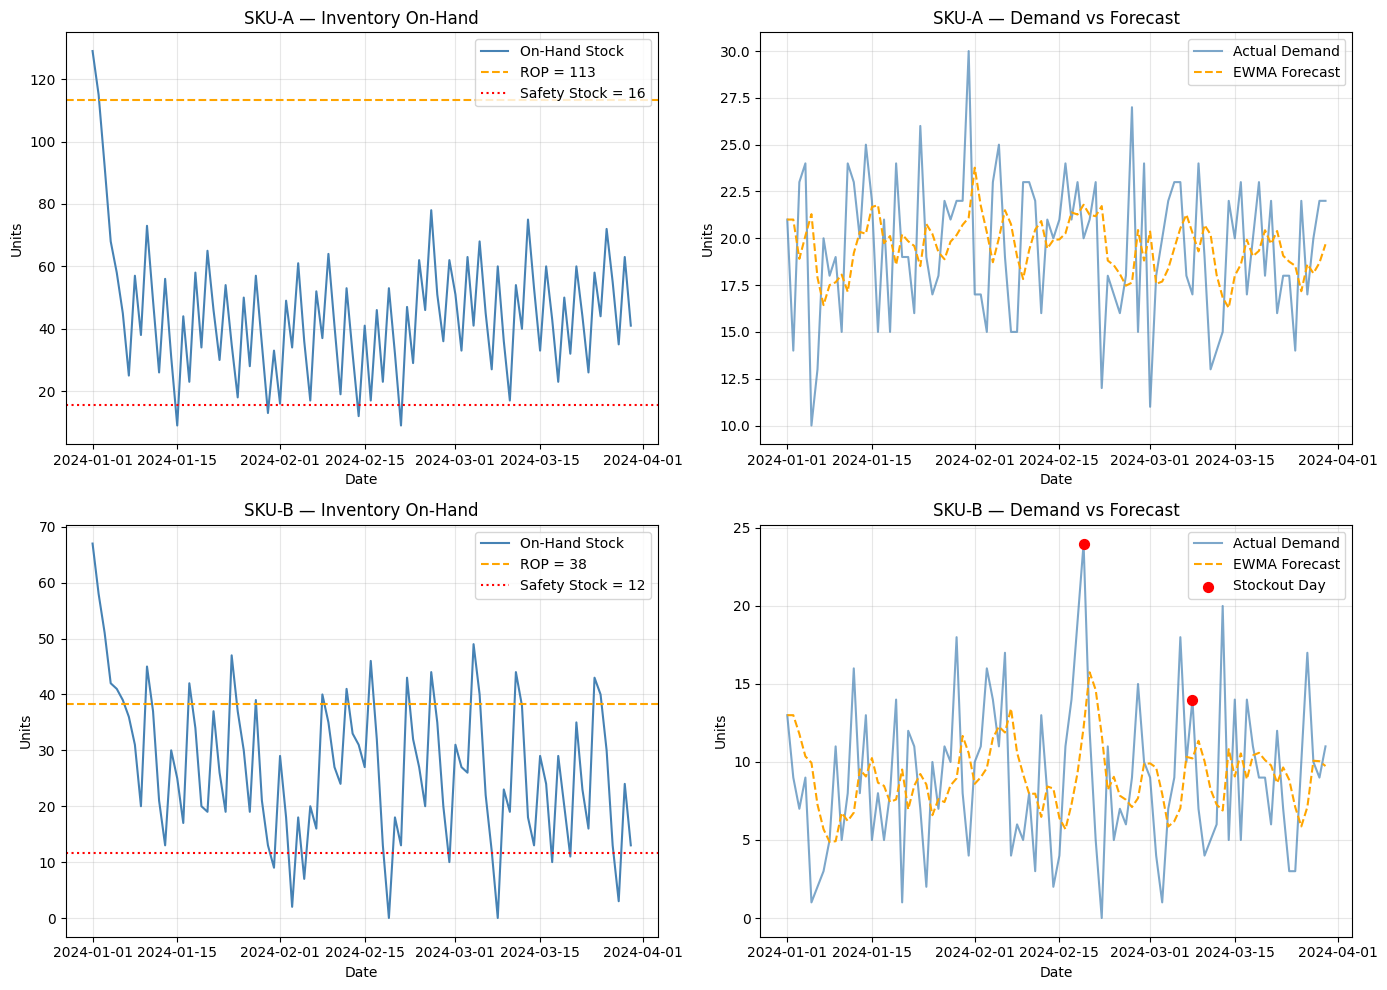

Chart saved to simulation_results.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(agents), 2, figsize=(14, 5*len(agents)))

# Make axes always 2D even with 1 SKU
if len(agents) == 1:
    axes = [axes]

for idx, (sku, agent) in enumerate(agents.items()):
    sku_log = log_df[log_df['sku'] == sku].copy()
    sku_log['date'] = pd.to_datetime(sku_log['date'])

    # Plot 1: On-hand inventory over time
    ax1 = axes[idx][0]
    ax1.plot(sku_log['date'], sku_log['on_hand_eod'], label='On-Hand Stock', color='steelblue')
    ax1.axhline(y=sku_params[sku]['reorder_point'], color='orange',
                linestyle='--', label=f"ROP = {sku_params[sku]['reorder_point']:.0f}")
    ax1.axhline(y=sku_params[sku]['safety_stock'], color='red',
                linestyle=':', label=f"Safety Stock = {sku_params[sku]['safety_stock']:.0f}")
    ax1.set_title(f"{sku} — Inventory On-Hand")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Units")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Demand vs forecast
    ax2 = axes[idx][1]
    ax2.plot(sku_log['date'], sku_log['actual_demand'], label='Actual Demand',
             color='steelblue', alpha=0.7)
    ax2.plot(sku_log['date'], sku_log['forecast'], label='EWMA Forecast',
             color='orange', linestyle='--')

    # Mark stockout days
    stockouts = sku_log[sku_log['units_short'] > 0]
    if len(stockouts) > 0:
        ax2.scatter(stockouts['date'], stockouts['actual_demand'],
                   color='red', zorder=5, label='Stockout Day', s=50)

    ax2.set_title(f"{sku} — Demand vs Forecast")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Units")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('simulation_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart saved to simulation_results.png")